In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

print("Bibliotecas carregadas ✅")

Bibliotecas carregadas ✅


In [2]:
df = pd.read_csv('../data/raw/telco_churn.csv')
print(f"Shape: {df.shape}")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("=== TIPOS E NULOS ===")
print(df.info())

=== TIPOS E NULOS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  70

In [5]:
print("=== TOTAL CHARGES PROBLEMÁTICO ===")
print(df['TotalCharges'].unique()[:20])

# Not a number?
invalidos = pd.to_numeric(df['TotalCharges'], errors='coerce').isna().sum()
print(f"\nValores inválidos em TotalCharges: {invalidos}")

=== TOTAL CHARGES PROBLEMÁTICO ===
['29.85' '1889.5' '108.15' '1840.75' '151.65' '820.5' '1949.4' '301.9'
 '3046.05' '3487.95' '587.45' '326.8' '5681.1' '5036.3' '2686.05'
 '7895.15' '1022.95' '7382.25' '528.35' '1862.9']

Valores inválidos em TotalCharges: 11


In [6]:
print("=== DISTRIBUIÇÃO DO CHURN ===")
print(df['Churn'].value_counts())
print(f"\nTaxa de churn: {df['Churn'].value_counts(normalize=True)['Yes']:.1%}")

=== DISTRIBUIÇÃO DO CHURN ===
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Taxa de churn: 26.5%


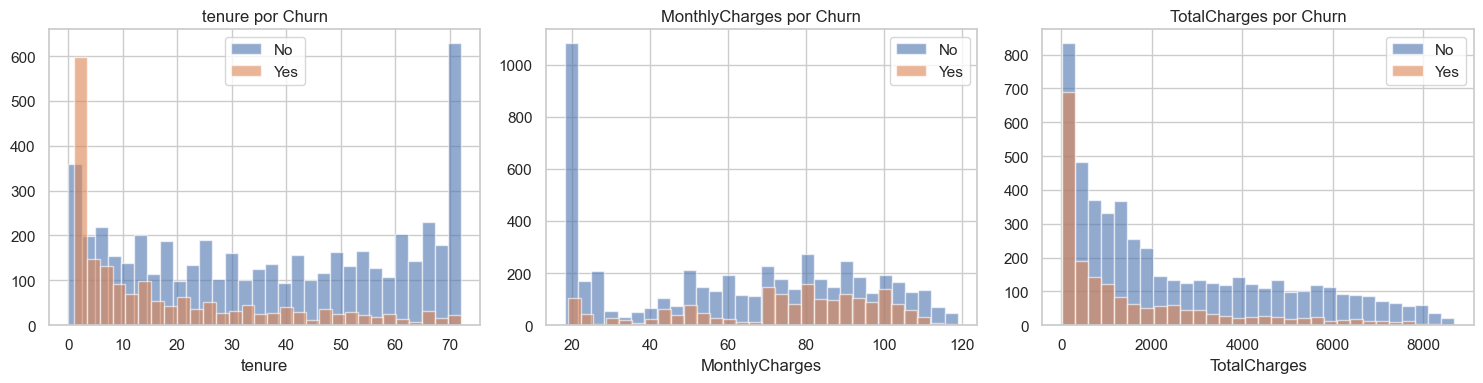

In [8]:
numericas = ['tenure', 'MonthlyCharges', 'TotalCharges']
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(numericas):
    df.groupby('Churn')[col].hist(alpha=0.6, ax=axes[i], bins=30)
    axes[i].set_title(f'{col} por Churn')
    axes[i].set_xlabel(col)
    axes[i].legend(['No', 'Yes'])
plt.tight_layout()
plt.show()

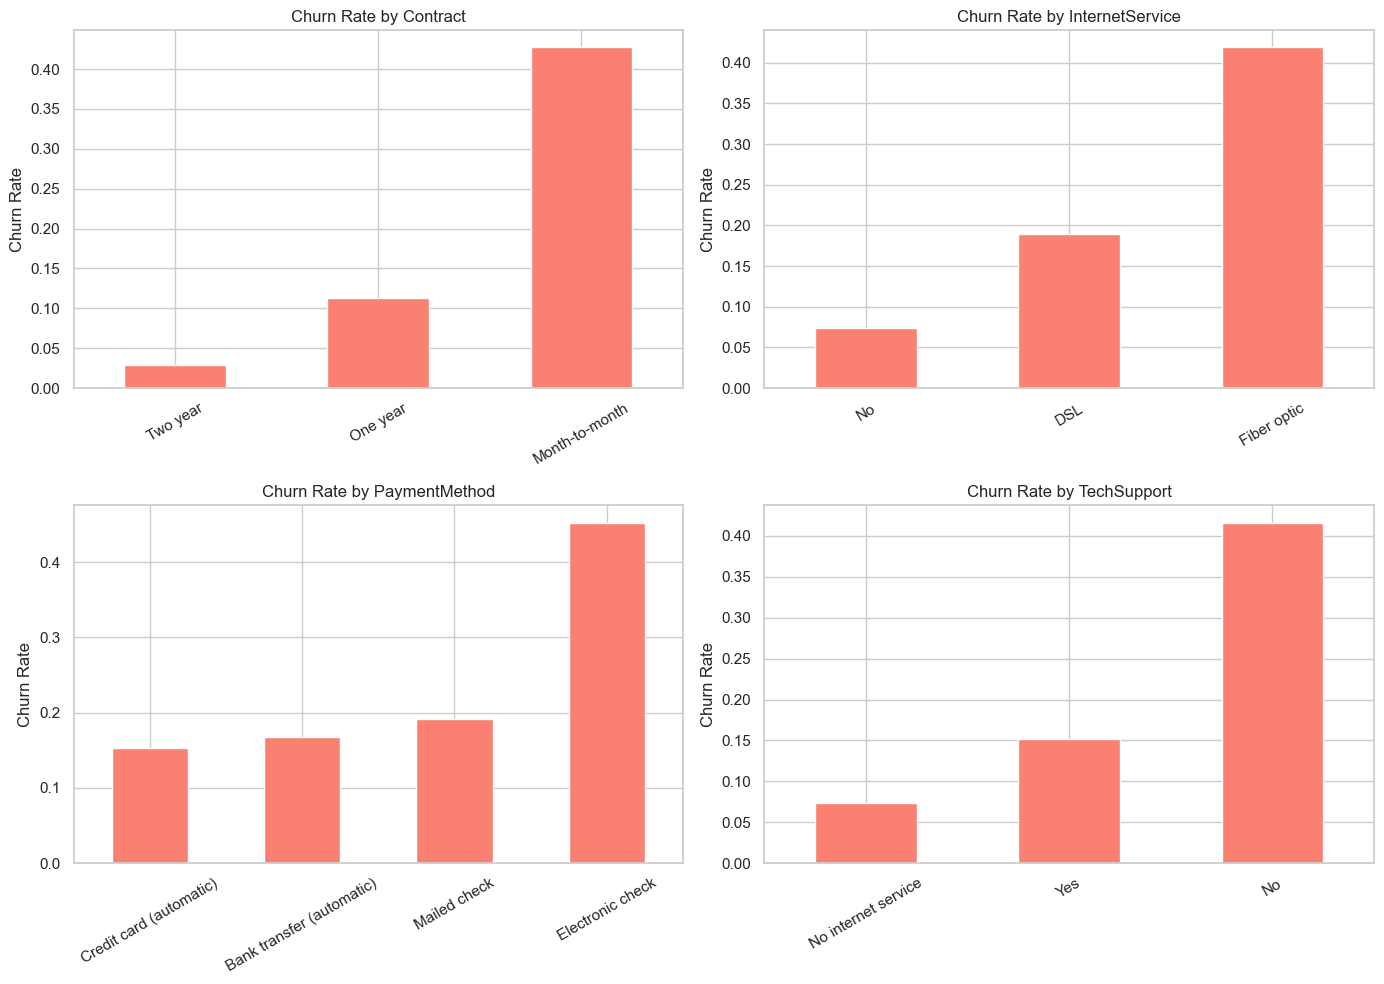

In [9]:
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean())
    churn_rate.sort_values().plot(kind='bar', ax=axes[i], color='salmon')
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

Contract:

Month-to-month → 42% churn 🔴
One year → 11% churn
Two year → 3% churn ✅
✅ Strongest predictor in the dataset

InternetService:

Fiber optic → 41% churn 🔴 (expensive, competitive market)
DSL → 19% churn
No internet → 7% churn
✅ Very strong predictor

PaymentMethod:

Electronic check → 45% churn 🔴 (manual, less committed customers)
Automatic payments → ~15% churn ✅
✅ Strong predictor — automatic payment = loyalty signal

TechSupport:

No tech support → 41% churn 🔴
Has tech support → 15% churn ✅
✅ Strong predictor — supported customers stay longer

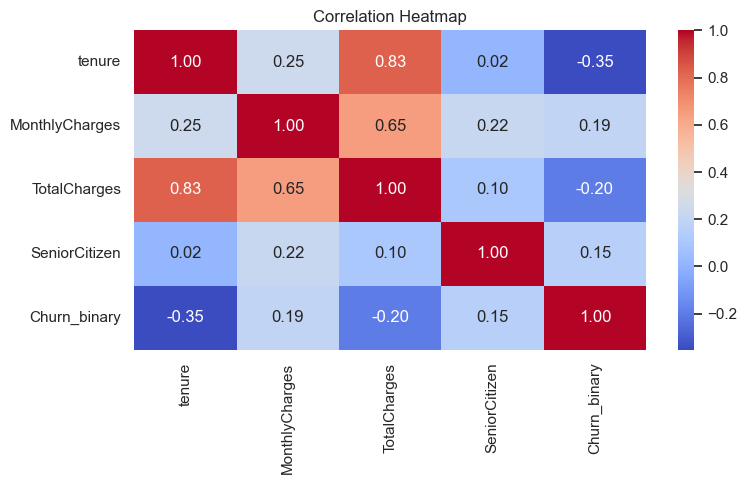

In [10]:
df_corr = df.copy()
df_corr['TotalCharges'] = pd.to_numeric(df_corr['TotalCharges'], errors='coerce')
df_corr['Churn_binary'] = (df_corr['Churn'] == 'Yes').astype(int)

fig, ax = plt.subplots(figsize=(8, 5))
corr = df_corr[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_binary']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()